<a href="https://colab.research.google.com/github/mjgpinheiro/Econophysics/blob/main/Analisador_Opcoes_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Analisador de Opções v2 — IV, Gregos, Regime e Sugestão de Estratégia

**Novidades da v2** (cada uma ataca uma limitação da v1):

| Limitação v1 | Solução v2 |
|---|---|
| IV rank aproximado via vol realizada | Cascata: **IV histórica real do IB** → **índice de vol (^VIX/^VXN)** para SPY/QQQ → **histórico próprio de IV** acumulado em CSV a cada execução → só então proxy RV |
| Sinal direcional simplista | **Score composto** (−100..+100): tendência SMA, momentum multi-horizonte, RSI, posição na banda 52 semanas |
| Strikes ilíquidos / mid desfasado | **Score de liquidez** por strike (spread %, volume, open interest) + aviso por perna escolhida |
| BSM europeu para opções americanas | **Árvore binomial CRR americana** valida cada perna e quantifica o prémio de exercício antecipado |
| Sem POP, gestão nem dimensionamento | **Probabilidade de lucro** (integração da densidade risk-neutral), P&L esperado, prob. de tocar o strike curto, **dimensionamento por risco máximo**, **plano de gestão** (alvo 50%, stop, saída a 21 DTE) |
| — | **Term structure de IV** (contango/backwardation), **skew 25Δ** (risk reversal) como sinais adicionais, **backtest proxy** da regra de venda de prémio, **gestor de posições abertas no IB**, célula de **alertas** |

---
⚠️ **Ferramenta educativa — não é aconselhamento financeiro.** Estratégias de venda de prémio podem perder muito mais do que o crédito recebido. Paper trading primeiro, sempre.


In [1]:
# @title 1) Instalação { display-mode: "form" }
%pip install -q yfinance ib_async
print("Dependências instaladas ✔")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 16.7 MB/s eta 0:00:00
Dependências instaladas ✔


In [2]:
# @title 2) Núcleo matemático: BSM, gregos, IV, árvore americana (CRR), POP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime
import os

# ---------- Black-Scholes-Merton (europeu) ----------
def bs_d1_d2(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return d1, d1 - sigma*np.sqrt(T)

def bs_price(S, K, T, r, sigma, kind="call", q=0.0):
    if T <= 0 or sigma <= 0:
        return max(S-K, 0.0) if kind == "call" else max(K-S, 0.0)
    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)
    if kind == "call":
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, kind="call", q=0.0):
    """Vega por ponto de vol (1%); theta por dia de calendário."""
    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)
    pdf = norm.pdf(d1)
    delta = np.exp(-q*T)*(norm.cdf(d1) if kind == "call" else norm.cdf(d1)-1)
    gamma = np.exp(-q*T)*pdf/(S*sigma*np.sqrt(T))
    vega  = S*np.exp(-q*T)*pdf*np.sqrt(T)/100.0
    if kind == "call":
        theta = (-S*np.exp(-q*T)*pdf*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)
                 + q*S*np.exp(-q*T)*norm.cdf(d1))/365.0
        rho = K*T*np.exp(-r*T)*norm.cdf(d2)/100.0
    else:
        theta = (-S*np.exp(-q*T)*pdf*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)
                 - q*S*np.exp(-q*T)*norm.cdf(-d1))/365.0
        rho = -K*T*np.exp(-r*T)*norm.cdf(-d2)/100.0
    return dict(delta=float(delta), gamma=float(gamma), vega=float(vega),
                theta=float(theta), rho=float(rho))

def implied_vol(price, S, K, T, r, kind="call", q=0.0):
    """Inversão numérica de BSM (Brent). Única porque vega>0. Olá, Marcelo. 👋"""
    lo = max(S*np.exp(-q*T)-K*np.exp(-r*T), 0.0) if kind=="call" else max(K*np.exp(-r*T)-S*np.exp(-q*T), 0.0)
    if not np.isfinite(price) or price <= lo + 1e-10 or T <= 0:
        return np.nan
    try:
        return brentq(lambda s: bs_price(S,K,T,r,s,kind,q)-price, 1e-4, 5.0, xtol=1e-8)
    except ValueError:
        return np.nan

# ---------- Árvore binomial CRR (opções AMERICANAS) ----------
def crr_price(S, K, T, r, sigma, kind="call", q=0.0, steps=300, american=True):
    dt = T/steps
    u = np.exp(sigma*np.sqrt(dt)); d = 1/u
    p = (np.exp((r-q)*dt)-d)/(u-d)
    disc = np.exp(-r*dt)
    j = np.arange(steps+1)
    ST = S * u**(steps-j) * d**j
    V = np.maximum(ST-K, 0) if kind=="call" else np.maximum(K-ST, 0)
    for n in range(steps-1, -1, -1):
        j = np.arange(n+1)
        Sn = S * u**(n-j) * d**j
        V = disc*(p*V[:-1] + (1-p)*V[1:])
        if american:
            ex = np.maximum(Sn-K, 0) if kind=="call" else np.maximum(K-Sn, 0)
            V = np.maximum(V, ex)
    return float(V[0])

def premio_exercicio_antecipado(S, K, T, r, sigma, kind, q=0.0):
    """Diferença (americana CRR − europeia BSM). Quantifica o desvio do modelo europeu."""
    if not np.isfinite(sigma) or sigma <= 0:
        return np.nan
    return crr_price(S,K,T,r,sigma,kind,q,steps=200) - bs_price(S,K,T,r,sigma,kind,q)

# ---------- Probabilidade de lucro e P&L esperado ----------
def payoff_expiracao(legs, Sg):
    pnl = np.zeros_like(Sg, dtype=float)
    for L in legs:
        intr = np.maximum(Sg-L["strike"],0) if L["kind"]=="call" else np.maximum(L["strike"]-Sg,0)
        pnl += (-1 if L["lado"]=="vender" else 1)*(intr - L["mid"])*L.get("qty",1)
    return pnl*100  # 1 contrato = 100 ações

def pop_e_epnl(legs, S, T, r, sigma, q=0.0, n=4000):
    """POP e E[P&L] na expiração sob densidade lognormal *risk-neutral*.
    Nota honesta: risk-neutral ⇒ E[P&L] de uma posição a preço justo ≈ 0; o teu edge
    real vem de vender IV acima da vol que se realiza (medida real, não risk-neutral)."""
    Sg = np.linspace(S*0.4, S*2.2, n)
    mu = np.log(S)+(r-q-0.5*sigma**2)*T; sd = sigma*np.sqrt(T)
    pdf = np.exp(-(np.log(Sg)-mu)**2/(2*sd**2))/(Sg*sd*np.sqrt(2*np.pi))
    pdf /= np.trapezoid(pdf, Sg)
    pnl = payoff_expiracao(legs, Sg)
    return float(np.trapezoid(pdf*(pnl>0), Sg)), float(np.trapezoid(pdf*pnl, Sg))

def prob_tocar(delta_abs):
    """Heurística de traders: P(tocar o strike antes da expiração) ≈ 2×P(expirar ITM) ≈ 2×|Δ|."""
    return min(1.0, 2.0*abs(delta_abs))

# auto-testes
_c = bs_price(100,100,.25,.04,.30,"call")
assert abs(implied_vol(_c,100,100,.25,.04,"call")-.30) < 1e-6
assert abs(crr_price(100,100,.25,.05,.30,"put",steps=800,american=False)-bs_price(100,100,.25,.05,.30,"put")) < .01
assert crr_price(100,140,.25,.05,.30,"put") > bs_price(100,140,.25,.05,.30,"put") + .5  # early exercise premium
print("Núcleo matemático v2 OK ✔ (europeu, americano e inversões)")

Núcleo matemático v2 OK ✔ (europeu, americano e inversões)


In [3]:
# @title 3) Configuração { display-mode: "form" }
TICKER        = "SPY"       # @param {type:"string"}
FONTE         = "yfinance"  # @param ["yfinance", "ibkr"]
DTE_ALVO      = 35          # @param {type:"integer"}
TAXA_JURO     = 0.042       # @param {type:"number"}
CAPITAL       = 25000       # @param {type:"number"}  — capital da conta (para dimensionamento)
RISCO_MAX_PCT = 0.02        # @param {type:"number"}  — risco máx. por trade (2% é conservador)
N_EXPIRACOES_TERM = 4       # expirações a usar na term structure (7–90 DTE)
DELTA_SHORT_CONDOR, DELTA_LONG_CONDOR = 0.20, 0.10
DELTA_SHORT_SPREAD, LARGURA_SPREAD_PCT = 0.30, 0.03
SPREAD_MAX_PCT = 0.10       # rejeitar strikes com (ask-bid)/mid acima disto
MIN_OI = 50                 # open interest mínimo para uma perna "confortável"
INDICES_VOL = {"SPY": "^VIX", "^GSPC": "^VIX", "QQQ": "^VXN", "^NDX": "^VXN"}
print(f"Config: {TICKER} | DTE alvo {DTE_ALVO} | capital {CAPITAL:,.0f} | risco/trade {RISCO_MAX_PCT:.0%}")

Config: SPY | DTE alvo 35 | capital 25,000 | risco/trade 2%


## 4) Dados de mercado

`yfinance` funciona diretamente no Colab (cotações ~15 min de atraso — bom para análise). `ibkr` dá dados em tempo real e **IV histórica verdadeira**, mas exige TWS/Gateway na tua máquina → corre o notebook localmente (o Colab não vê o teu `localhost`). A secção IB está no fim.


In [4]:
# @title 4a) Fetch yfinance: spot, histórico, cadeia principal com métricas de liquidez
import yfinance as yf

tk = yf.Ticker(TICKER)
hist = tk.history(period="2y", auto_adjust=True)
if hist.empty:
    raise RuntimeError(f"Sem histórico para {TICKER}.")
SPOT = float(hist["Close"].iloc[-1])
try:
    DIV_YIELD = float(tk.info.get("dividendYield") or 0.0)
    if DIV_YIELD > 1: DIV_YIELD /= 100.0
except Exception:
    DIV_YIELD = 0.0

hoje = pd.Timestamp.now(tz="UTC").normalize()
exps = tk.options
if not exps: raise RuntimeError(f"{TICKER} sem opções no yfinance.")
dtes = {e: (pd.Timestamp(e, tz="UTC")-hoje).days for e in exps}
EXPIRACAO = min(dtes, key=lambda e: abs(dtes[e]-DTE_ALVO))
DTE = max(dtes[EXPIRACAO], 1); T = DTE/365.0
chain = tk.option_chain(EXPIRACAO)

def preparar(df, kind):
    df = df[["strike","bid","ask","lastPrice","volume","openInterest"]].copy()
    df["mid"] = np.where((df.bid>0)&(df.ask>0), (df.bid+df.ask)/2, df.lastPrice)
    df["spread_pct"] = np.where(df.mid>0, (df.ask-df.bid)/df.mid, np.inf)
    df["volume"] = df.volume.fillna(0); df["openInterest"] = df.openInterest.fillna(0)
    # score de liquidez 0-100: spread apertado + OI + volume
    df["liq"] = (np.clip(1 - df.spread_pct/SPREAD_MAX_PCT, 0, 1)*50
                 + np.clip(df.openInterest/500, 0, 1)*30
                 + np.clip(df.volume/200, 0, 1)*20).round(0)
    df["kind"] = kind
    df = df[(df.mid > 0.02) & (df.strike > SPOT*0.6) & (df.strike < SPOT*1.4)
            & (df.spread_pct < SPREAD_MAX_PCT*3)]   # corta o lixo extremo; o resto é penalizado no score
    return df

calls, puts = preparar(chain.calls, "call"), preparar(chain.puts, "put")
print(f"{TICKER}: spot={SPOT:.2f} | div≈{DIV_YIELD:.2%} | expiração {EXPIRACAO} ({DTE} DTE)")
print(f"{len(calls)} calls / {len(puts)} puts após filtro de liquidez (spread<{SPREAD_MAX_PCT*3:.0%} do mid)")

SPY: spot=747.71 | div≈1.01% | expiração 2026-08-14 (38 DTE)
36 calls / 34 puts após filtro de liquidez (spread<30% do mid)


IV ATM = 13.80%
Prémio de exercício antecipado ATM: put +0.1754 | call -0.0166 (1.46% do preço da put) — se <1%, o BSM europeu é adequado aqui.


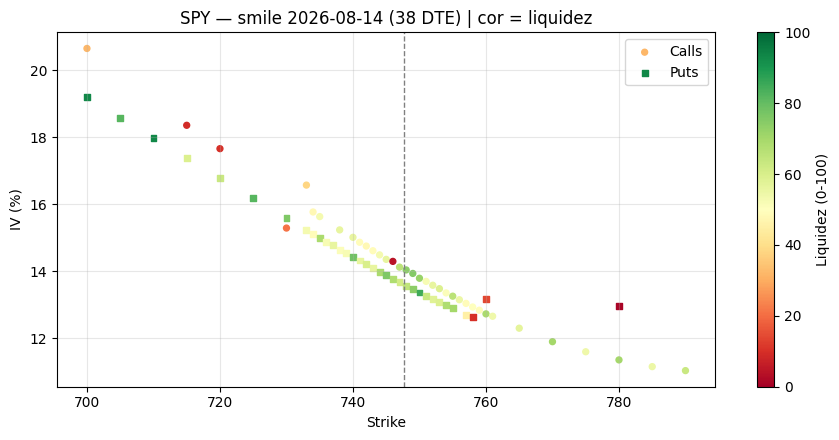

In [5]:
# @title 4b) IV, gregos e validação americana por strike + smile
def enriquecer(df):
    out = []
    for _, row in df.iterrows():
        iv = implied_vol(row.mid, SPOT, row.strike, T, TAXA_JURO, row.kind, DIV_YIELD)
        if not np.isfinite(iv): continue
        g = bs_greeks(SPOT, row.strike, T, TAXA_JURO, iv, row.kind, DIV_YIELD)
        out.append({**row.to_dict(), "iv": iv, **g})
    return pd.DataFrame(out).sort_values("strike").reset_index(drop=True)

calls, puts = enriquecer(calls), enriquecer(puts)
iv_c = calls.iloc[(calls.strike-SPOT).abs().argsort()[:1]].iv.mean()
iv_p = puts.iloc[(puts.strike-SPOT).abs().argsort()[:1]].iv.mean()
IV_ATM = float(np.nanmean([iv_c, iv_p]))

# desvio americano vs europeu na zona ATM (quantifica a limitação do BSM)
_eep_put  = premio_exercicio_antecipado(SPOT, SPOT, T, TAXA_JURO, IV_ATM, "put",  DIV_YIELD)
_eep_call = premio_exercicio_antecipado(SPOT, SPOT, T, TAXA_JURO, IV_ATM, "call", DIV_YIELD)
_ref = bs_price(SPOT, SPOT, T, TAXA_JURO, IV_ATM, "put", DIV_YIELD)
print(f"IV ATM = {IV_ATM:.2%}")
print(f"Prémio de exercício antecipado ATM: put {_eep_put:+.4f} | call {_eep_call:+.4f} "
      f"({abs(_eep_put)/_ref:.2%} do preço da put) — se <1%, o BSM europeu é adequado aqui.")

fig, ax = plt.subplots(figsize=(9,4.5))
sc = ax.scatter(calls.strike, calls.iv*100, c=calls.liq, cmap="RdYlGn", vmin=0, vmax=100, s=18, label="Calls")
ax.scatter(puts.strike, puts.iv*100, c=puts.liq, cmap="RdYlGn", vmin=0, vmax=100, s=18, marker="s", label="Puts")
ax.axvline(SPOT, color="gray", ls="--", lw=1)
plt.colorbar(sc, label="Liquidez (0-100)")
ax.set_title(f"{TICKER} — smile {EXPIRACAO} ({DTE} DTE) | cor = liquidez")
ax.set_xlabel("Strike"); ax.set_ylabel("IV (%)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

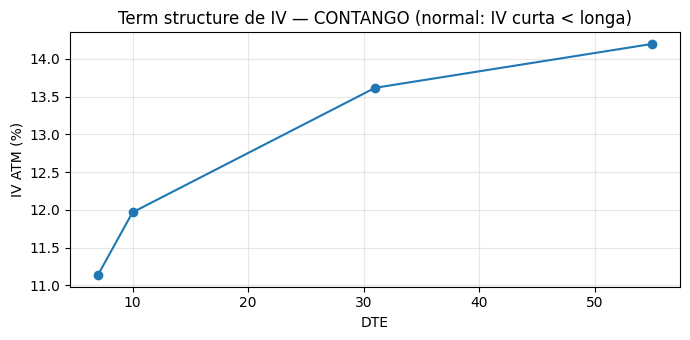

Histórico próprio de IV: 1 observações em iv_history_SPY.csv (ainda insuficiente para IV rank próprio — vai acumulando)


/tmp/ipykernel_3093/1941782391.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iv_hist = pd.concat([iv_hist, pd.DataFrame([{"date": hoje_d, "iv_atm": IV_ATM}])], ignore_index=True)


In [6]:
# @title 4c) Term structure de IV + histórico próprio de IV (persistência)
# --- Term structure: IV ATM em várias expirações (contango/backwardation) ---
term_rows = []
try:
    candidatos = [e for e in exps if 7 <= dtes[e] <= 90]
    passo = max(1, len(candidatos)//N_EXPIRACOES_TERM)
    for e in candidatos[::passo][:N_EXPIRACOES_TERM]:
        ch = tk.option_chain(e)
        Te = max(dtes[e],1)/365.0
        cc = ch.calls; cc = cc[(cc.strike-SPOT).abs() < SPOT*0.02]
        pp = ch.puts;  pp = pp[(pp.strike-SPOT).abs() < SPOT*0.02]
        ivs = []
        for df_, kd in ((cc,"call"), (pp,"put")):
            for _, rw in df_.iterrows():
                mid = (rw.bid+rw.ask)/2 if (rw.bid>0 and rw.ask>0) else rw.lastPrice
                iv = implied_vol(mid, SPOT, rw.strike, Te, TAXA_JURO, kd, DIV_YIELD)
                if np.isfinite(iv): ivs.append(iv)
        if ivs: term_rows.append(dict(expiracao=e, dte=dtes[e], iv_atm=float(np.median(ivs))))
except Exception as ex:
    print("Term structure indisponível:", ex)

TERM_DF = pd.DataFrame(term_rows).sort_values("dte") if term_rows else pd.DataFrame()
TERM_SLOPE = np.nan
if len(TERM_DF) >= 2:
    TERM_SLOPE = float(TERM_DF.iv_atm.iloc[-1] - TERM_DF.iv_atm.iloc[0])  # longo − curto
    estado = "CONTANGO (normal: IV curta < longa)" if TERM_SLOPE > 0 else "BACKWARDATION ⚠️ (stress: IV curta > longa)"
    fig, ax = plt.subplots(figsize=(7,3.5))
    ax.plot(TERM_DF.dte, TERM_DF.iv_atm*100, "o-")
    ax.set_title(f"Term structure de IV — {estado}")
    ax.set_xlabel("DTE"); ax.set_ylabel("IV ATM (%)"); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

# --- Histórico próprio de IV: cada execução grava a IV ATM de hoje num CSV ---
# Ao fim de ~2 meses de execuções diárias tens um IV rank verdadeiro, teu.
IV_CSV = f"iv_history_{TICKER}.csv"   # no Colab, monta o Google Drive p/ persistir entre sessões
iv_hist = pd.read_csv(IV_CSV, parse_dates=["date"]) if os.path.exists(IV_CSV) else pd.DataFrame(columns=["date","iv_atm"])
hoje_d = pd.Timestamp.now().normalize()
if iv_hist.empty or (iv_hist.date.max() < hoje_d):
    iv_hist = pd.concat([iv_hist, pd.DataFrame([{"date": hoje_d, "iv_atm": IV_ATM}])], ignore_index=True)
    iv_hist.to_csv(IV_CSV, index=False)
print(f"Histórico próprio de IV: {len(iv_hist)} observações em {IV_CSV}"
      + ("" if len(iv_hist) >= 40 else " (ainda insuficiente para IV rank próprio — vai acumulando)"))

In [7]:
# @title 5) Regime: IV rank real (cascata), direção composta, skew 25Δ, VRP
ret = np.log(hist["Close"]/hist["Close"].shift(1)).dropna()
RV20 = float(ret.tail(20).std()*np.sqrt(252)); RV60 = float(ret.tail(60).std()*np.sqrt(252))
VRP_RATIO = IV_ATM/RV20 if RV20 > 0 else np.nan

# ---------- IV RANK: cascata de fontes, da melhor para a pior ----------
IV_PCTL, IV_RANK_FONTE = np.nan, ""
# (1º) IV histórica do IB — preenchida na secção IB se FONTE='ibkr'
# (2º) índice de vol oficial (VIX/VXN) para SPY/QQQ e índices
if TICKER in INDICES_VOL:
    try:
        vix = yf.Ticker(INDICES_VOL[TICKER]).history(period="1y")["Close"]/100.0
        if len(vix) > 100:
            IV_PCTL = float((vix < IV_ATM).mean()*100)
            iv_min, iv_max = float(vix.min()), float(vix.max())
            IV_RANK = float((IV_ATM-iv_min)/(iv_max-iv_min)*100) if iv_max > iv_min else np.nan
            IV_RANK_FONTE = f"índice {INDICES_VOL[TICKER]} (IV real de mercado)"
    except Exception as e:
        print("Índice de vol indisponível:", e)
# (3º) histórico próprio acumulado
if np.isnan(IV_PCTL) and len(iv_hist) >= 40:
    serie = iv_hist.iv_atm
    IV_PCTL = float((serie < IV_ATM).mean()*100)
    IV_RANK = float((IV_ATM-serie.min())/(serie.max()-serie.min())*100)
    IV_RANK_FONTE = f"histórico próprio ({len(iv_hist)} obs.)"
# (4º) proxy via vol realizada — o fallback honesto da v1
if np.isnan(IV_PCTL):
    rv_hist = (ret.rolling(20).std()*np.sqrt(252)).dropna().tail(252)
    IV_PCTL = float((rv_hist < IV_ATM).mean()*100)
    IV_RANK = IV_PCTL
    IV_RANK_FONTE = "proxy RV20 (aproximação — acumula histórico ou usa IB para melhorar)"

# ---------- DIREÇÃO: score composto −100..+100 ----------
c = hist["Close"]
sma20, sma50, sma100 = c.rolling(20).mean().iloc[-1], c.rolling(50).mean().iloc[-1], c.rolling(100).mean().iloc[-1]
mom20 = float(c.iloc[-1]/c.iloc[-21]-1); mom60 = float(c.iloc[-1]/c.iloc[-61]-1)
delta_c = c.diff()
ganho = delta_c.clip(lower=0).rolling(14).mean().iloc[-1]
perda = (-delta_c.clip(upper=0)).rolling(14).mean().iloc[-1]
RSI = float(100 - 100/(1 + ganho/perda)) if perda > 0 else 100.0
hi52, lo52 = float(c.tail(252).max()), float(c.tail(252).min())
pos52 = (SPOT-lo52)/(hi52-lo52) if hi52 > lo52 else 0.5

SCORE = (20*np.sign(SPOT-sma50) + 10*np.sign(sma20-sma50) + 10*np.sign(sma50-sma100)
         + float(np.clip(mom20*300, -15, 15)) + float(np.clip(mom60*150, -10, 10))
         + float(np.clip((RSI-50)*0.6, -18, 18)) + float(np.clip((pos52-0.5)*34, -17, 17)))
DIRECAO = "bullish" if SCORE > 30 else ("bearish" if SCORE < -30 else "neutro")

# ---------- SKEW 25Δ (risk reversal): medo de cauda ----------
try:
    p25 = puts.iloc[(puts.delta.abs()-0.25).abs().argsort()[:1]].iloc[0]
    c25 = calls.iloc[(calls.delta.abs()-0.25).abs().argsort()[:1]].iloc[0]
    SKEW_25D = float(p25.iv - c25.iv)   # em pontos de vol; positivo = puts mais caras (normal em equities)
except Exception:
    SKEW_25D = np.nan

MOVE_ESPERADO = SPOT*IV_ATM*np.sqrt(T)
print(f"RV20 {RV20:.2%} | RV60 {RV60:.2%} | IV ATM {IV_ATM:.2%} | IV/RV {VRP_RATIO:.2f}")
print(f"IV percentil: {IV_PCTL:.0f}%  |  IV rank: {IV_RANK:.0f}  ← fonte: {IV_RANK_FONTE}")
print(f"Direção: {DIRECAO.upper()} (score {SCORE:+.0f}; SMA/momentum/RSI {RSI:.0f}/pos 52w {pos52:.0%})")
if np.isfinite(SKEW_25D):
    aviso = " ⚠️ skew MUITO inclinado — mercado paga caro por proteção" if SKEW_25D > 0.06 else ""
    print(f"Skew 25Δ (put−call): {SKEW_25D*100:+.1f} pontos de vol{aviso}")
if np.isfinite(TERM_SLOPE):
    print(f"Term structure (longa−curta): {TERM_SLOPE*100:+.1f} p.v. "
          + ("(contango — normal)" if TERM_SLOPE > 0 else "⚠️ (backwardation — stress)"))
print(f"Movimento esperado ±1σ até {EXPIRACAO}: ±{MOVE_ESPERADO:.2f} ({MOVE_ESPERADO/SPOT:.1%})")

RV20 15.79% | RV60 13.30% | IV ATM 13.80% | IV/RV 0.87
IV percentil: 1%  |  IV rank: 2  ← fonte: índice ^VIX (IV real de mercado)
Direção: BULLISH (score +67; SMA/momentum/RSI 46/pos 52w 93%)
Skew 25Δ (put−call): +4.3 pontos de vol
Term structure (longa−curta): +3.1 p.v. (contango — normal)
Movimento esperado ±1σ até 2026-08-14: ±33.30 (4.5%)


In [8]:
# @title 6) Conselheiro v2 — decide com IV rank, direção, skew e term structure
def aconselhar(vrp_ratio, iv_pctl, direcao, skew, term_slope):
    iv_cara   = (vrp_ratio >= 1.15) and (iv_pctl >= 60)
    iv_barata = (vrp_ratio <= 0.90) or  (iv_pctl <= 25)
    notas = []
    if np.isfinite(skew) and skew > 0.06:
        notas.append("Skew 25Δ muito inclinado: puts OTM caríssimas — se venderes o lado da put, "
                     "recebes mais prémio, mas é o mercado a pagar por risco de queda real. "
                     "Considera afastar o strike da put ou enviesar o condor (asa da put mais larga).")
    if np.isfinite(term_slope) and term_slope < -0.01:
        notas.append("Term structure em backwardation: stress de curto prazo. Vender prémio aqui paga "
                     "bem mas o gama morde — reduz tamanho ou espera a normalização.")
    if np.isfinite(term_slope) and term_slope > 0.03 and iv_barata:
        notas.append("Contango acentuado + IV curta barata: calendars/diagonais (comprar curto, vender longo "
                     "— fora do âmbito desta versão) tornam-se interessantes.")

    if iv_cara and direcao == "neutro":
        return ("IRON CONDOR (vender prémio, risco definido)",
                "IV cara vs. realizada, IV rank elevado, sem tendência → vender vol dos dois lados. "
                "Theta+, vega−, gama− (o risco a vigiar).", notas)
    if iv_cara and direcao == "bullish":
        return ("BULL PUT SPREAD (credit spread)",
                "IV cara + viés altista → vender prémio no lado da put, risco definido.", notas)
    if iv_cara and direcao == "bearish":
        return ("BEAR CALL SPREAD (credit spread)",
                "IV cara + viés baixista → vender prémio no lado da call, risco definido.", notas)
    if iv_barata and direcao == "neutro":
        return ("LONG STRADDLE (comprar vol)",
                "IV barata vs. realizada → comprar movimento sem apostar na direção. Vega+, theta− "
                "(precisas do movimento DEPRESSA; ideal com catalisador à vista).", notas)
    if iv_barata and direcao == "bullish":
        return ("BULL CALL SPREAD (debit spread)", "IV barata + viés altista → comprar direção com custo contido.", notas)
    if iv_barata and direcao == "bearish":
        return ("BEAR PUT SPREAD (debit spread)", "IV barata + viés baixista → comprar puts em spread.", notas)
    return ("AGUARDAR / POSIÇÃO PEQUENA",
            "IV em linha com a realizada e sem edge claro. O melhor trade é muitas vezes não fazer trade.", notas)

ESTRATEGIA, JUSTIFICACAO, NOTAS = aconselhar(VRP_RATIO, IV_PCTL, DIRECAO, SKEW_25D, TERM_SLOPE)
print("═"*72); print(f"  SUGESTÃO: {ESTRATEGIA}"); print("═"*72)
print(JUSTIFICACAO)
for n in NOTAS: print(f"\n📌 {n}")

════════════════════════════════════════════════════════════════════════
  SUGESTÃO: BULL CALL SPREAD (debit spread)
════════════════════════════════════════════════════════════════════════
IV barata + viés altista → comprar direção com custo contido.

📌 Contango acentuado + IV curta barata: calendars/diagonais (comprar curto, vender longo — fora do âmbito desta versão) tornam-se interessantes.


── BULL CALL SPREAD (debit spread) | SPY 2026-08-14 (38 DTE) ──

  COMPRAR  1x CALL   751.00 @  12.78 (Δ=+0.50, IV=13.7%, liq=52)
  VENDER   1x CALL   775.00 @   3.01 (Δ=+0.20, IV=11.6%, liq=54)

  DÉBITO pago: 976.50 USD/estrutura
  Lucro máx: +1423.50 | Perda máx: -976.50 | R/R: 1.46
  Breakevens: 760.76 (spot 747.71)
  Probabilidade de lucro (risk-neutral, na expiração): 37%
  E[P&L] risk-neutral: -143.46 USD — perto de 0 é normal: o edge real está em VENDER IV 0.87× a vol realizada, não na densidade risk-neutral.
  P(tocar strike 775 antes da expiração) ≈ 39% — vais ver o strike ameaçado com frequência; faz parte.

  Gregos líquidos: Δ=+30.1 | vega=+29.2 USD/p.v. | theta=-9.0 USD/dia


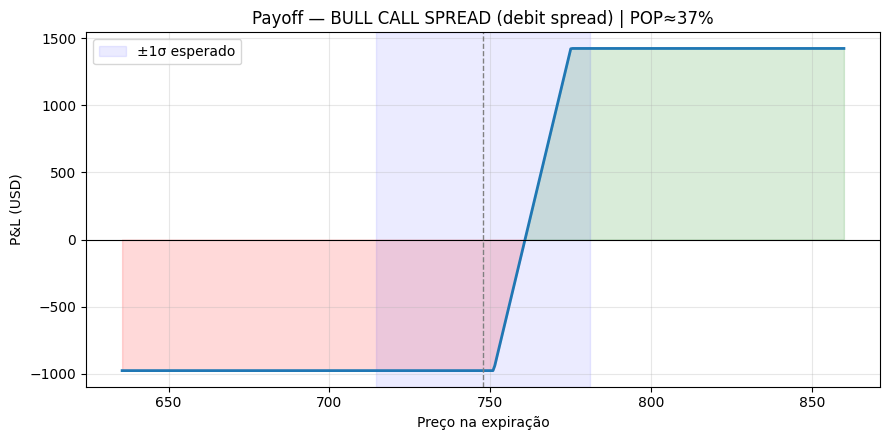

In [9]:
# @title 7) Pernas, POP, E[P&L], validação americana, liquidez e payoff
def strike_por_delta(df, alvo):
    return df.iloc[(df.delta.abs()-alvo).abs().argsort()[:1]].iloc[0]

def leg(row, lado, qty=1):
    return dict(kind=row.kind, strike=float(row.strike), mid=float(row.mid), iv=float(row.iv),
                delta=float(row.delta), vega=float(row.vega), theta=float(row.theta),
                liq=float(row.liq), lado=lado, qty=qty)

def montar_estrategia(nome):
    if "IRON CONDOR" in nome:
        sc, sp = strike_por_delta(calls, DELTA_SHORT_CONDOR), strike_por_delta(puts, DELTA_SHORT_CONDOR)
        lc = strike_por_delta(calls[calls.strike > sc.strike], DELTA_LONG_CONDOR)
        lp = strike_por_delta(puts[puts.strike < sp.strike], DELTA_LONG_CONDOR)
        return [leg(sp,"vender"), leg(lp,"comprar"), leg(sc,"vender"), leg(lc,"comprar")]
    if "BULL PUT" in nome:
        s = strike_por_delta(puts, DELTA_SHORT_SPREAD)
        l = puts.iloc[(puts.strike-(s.strike-SPOT*LARGURA_SPREAD_PCT)).abs().argsort()[:1]].iloc[0]
        return [leg(s,"vender"), leg(l,"comprar")]
    if "BEAR CALL" in nome:
        s = strike_por_delta(calls, DELTA_SHORT_SPREAD)
        l = calls.iloc[(calls.strike-(s.strike+SPOT*LARGURA_SPREAD_PCT)).abs().argsort()[:1]].iloc[0]
        return [leg(s,"vender"), leg(l,"comprar")]
    if "STRADDLE" in nome:
        cA = calls.iloc[(calls.strike-SPOT).abs().argsort()[:1]].iloc[0]
        pA = puts.iloc[(puts.strike-SPOT).abs().argsort()[:1]].iloc[0]
        return [leg(cA,"comprar"), leg(pA,"comprar")]
    if "BULL CALL" in nome:
        lc = strike_por_delta(calls, 0.50)
        sc = calls.iloc[(calls.strike-(lc.strike+SPOT*LARGURA_SPREAD_PCT)).abs().argsort()[:1]].iloc[0]
        return [leg(lc,"comprar"), leg(sc,"vender")]
    if "BEAR PUT" in nome:
        lp = strike_por_delta(puts, 0.50)
        sp = puts.iloc[(puts.strike-(lp.strike-SPOT*LARGURA_SPREAD_PCT)).abs().argsort()[:1]].iloc[0]
        return [leg(lp,"comprar"), leg(sp,"vender")]
    return []

LEGS = montar_estrategia(ESTRATEGIA)
PERDA_MAX = np.nan
if not LEGS:
    print("Regime 'aguardar' — sem pernas. Volta noutro dia. 🙂")
else:
    fluxo = sum((L["mid"] if L["lado"]=="vender" else -L["mid"]) for L in LEGS)*100
    print(f"── {ESTRATEGIA} | {TICKER} {EXPIRACAO} ({DTE} DTE) ──\n")
    for L in LEGS:
        eep = premio_exercicio_antecipado(SPOT, L["strike"], T, TAXA_JURO, L["iv"], L["kind"], DIV_YIELD)
        flag_liq = "" if L["liq"] >= 50 else "  ⚠️ liquidez fraca — usa ordem limite ao mid e sê paciente"
        flag_am  = "" if (not np.isfinite(eep) or eep < 0.01*max(L["mid"],0.01)*10) else f"  (americana +{eep:.3f} vs BSM)"
        print(f"  {L['lado'].upper():8s} 1x {L['kind'].upper():4s} {L['strike']:>8.2f} @ {L['mid']:>6.2f} "
              f"(Δ={L['delta']:+.2f}, IV={L['iv']:.1%}, liq={L['liq']:.0f}){flag_am}{flag_liq}")
    print(f"\n  {'CRÉDITO recebido' if fluxo>0 else 'DÉBITO pago'}: {abs(fluxo):.2f} USD/estrutura")

    Sg = np.linspace(SPOT*0.85, SPOT*1.15, 400)
    pnl = payoff_expiracao(LEGS, Sg)
    PERDA_MAX, LUCRO_MAX = float(pnl.min()), float(pnl.max())
    sinais = np.sign(pnl); cruz = np.where(np.diff(sinais)!=0)[0]
    bes = [float(Sg[i]-pnl[i]*(Sg[i+1]-Sg[i])/(pnl[i+1]-pnl[i])) for i in cruz]
    POP, EPNL = pop_e_epnl(LEGS, SPOT, T, TAXA_JURO, IV_ATM, DIV_YIELD)

    print(f"  Lucro máx: {LUCRO_MAX:+.2f} | Perda máx: {PERDA_MAX:+.2f} | R/R: {abs(LUCRO_MAX/PERDA_MAX):.2f}"
          if PERDA_MAX != 0 else f"  Lucro máx: {LUCRO_MAX:+.2f}")
    if bes: print(f"  Breakevens: {', '.join(f'{b:.2f}' for b in bes)} (spot {SPOT:.2f})")
    print(f"  Probabilidade de lucro (risk-neutral, na expiração): {POP:.0%}")
    print(f"  E[P&L] risk-neutral: {EPNL:+.2f} USD — perto de 0 é normal: o edge real está em VENDER "
          f"IV {VRP_RATIO:.2f}× a vol realizada, não na densidade risk-neutral.")
    for L in LEGS:
        if L["lado"] == "vender":
            print(f"  P(tocar strike {L['strike']:.0f} antes da expiração) ≈ {prob_tocar(L['delta']):.0%} "
                  f"— vais ver o strike ameaçado com frequência; faz parte.")

    net = {k: sum((-1 if L['lado']=='vender' else 1)*L[k]*100 for L in LEGS) for k in ("delta","vega","theta")}
    print(f"\n  Gregos líquidos: Δ={net['delta']:+.1f} | vega={net['vega']:+.1f} USD/p.v. | theta={net['theta']:+.1f} USD/dia")

    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.plot(Sg, pnl, lw=2)
    ax.fill_between(Sg, pnl, 0, where=pnl>=0, alpha=.15, color="green")
    ax.fill_between(Sg, pnl, 0, where=pnl<0, alpha=.15, color="red")
    ax.axhline(0, color="k", lw=.8); ax.axvline(SPOT, color="gray", ls="--", lw=1)
    ax.axvspan(SPOT-MOVE_ESPERADO, SPOT+MOVE_ESPERADO, alpha=.08, color="blue", label="±1σ esperado")
    ax.set_title(f"Payoff — {ESTRATEGIA} | POP≈{POP:.0%}")
    ax.set_xlabel("Preço na expiração"); ax.set_ylabel("P&L (USD)"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

In [10]:
# @title 7b) Dimensionamento por risco e plano de gestão da posição
if LEGS and np.isfinite(PERDA_MAX) and PERDA_MAX < 0:
    risco_por_estrutura = abs(PERDA_MAX)
    n_estruturas = int(CAPITAL*RISCO_MAX_PCT // risco_por_estrutura)
    print(f"── Dimensionamento ──")
    print(f"  Capital: {CAPITAL:,.0f} USD | risco máx/trade: {RISCO_MAX_PCT:.0%} = {CAPITAL*RISCO_MAX_PCT:,.0f} USD")
    print(f"  Perda máx por estrutura: {risco_por_estrutura:,.2f} USD")
    print(f"  → Tamanho sugerido: {max(n_estruturas,0)} estrutura(s)"
          + ("  ⚠️ nem 1 estrutura cabe no teu limite de risco — reduz a largura ou passa." if n_estruturas < 1 else ""))

    credito = fluxo > 0
    print(f"\n── Plano de gestão (define ANTES de entrar) ──")
    if credito:
        print(f"  🎯 Alvo de lucro: fechar a 50% do crédito → recomprar a {abs(fluxo)*0.5/100:.2f} por estrutura")
        print(f"  🛑 Stop: fechar se a perda atingir ~2× o crédito recebido ({abs(fluxo)*2:.0f} USD)")
        print(f"  ⏳ Tempo: fechar ou rolar a 21 DTE ({(pd.Timestamp(EXPIRACAO)-pd.Timedelta(days=21)).date()}) — "
              f"depois disso o gama acelera e o theta já foi quase todo colhido")
        print(f"  🔄 Rolar: se um strike curto for testado com >21 DTE, rola o lado NÃO testado para perto "
              f"(recolhe mais crédito) ou rola a estrutura para a expiração seguinte POR CRÉDITO — nunca por débito")
    else:
        print(f"  🎯 Alvo: fechar a +100% do débito, ou parcial a +50%")
        print(f"  🛑 Stop: fechar se perder 50% do débito pago ({abs(fluxo)*0.5:.0f} USD)")
        print(f"  ⏳ Tempo: se em {max(DTE-21,7)} dias o movimento não veio, sai — o theta come o resto")
    print(f"  📓 Regra de ouro: o tamanho é a única variável que controlas totalmente. Erros de tamanho matam contas;"
          f" erros de direção só as arranham.")
else:
    print("Sem posição a dimensionar neste regime.")

── Dimensionamento ──
  Capital: 25,000 USD | risco máx/trade: 2% = 500 USD
  Perda máx por estrutura: 976.50 USD
  → Tamanho sugerido: 0 estrutura(s)  ⚠️ nem 1 estrutura cabe no teu limite de risco — reduz a largura ou passa.

── Plano de gestão (define ANTES de entrar) ──
  🎯 Alvo: fechar a +100% do débito, ou parcial a +50%
  🛑 Stop: fechar se perder 50% do débito pago (488 USD)
  ⏳ Tempo: se em 17 dias o movimento não veio, sai — o theta come o resto
  📓 Regra de ouro: o tamanho é a única variável que controlas totalmente. Erros de tamanho matam contas; erros de direção só as arranham.


## 8) Backtest proxy da regra de venda de prémio

Backtest **honesto quanto às suas limitações**: sem dados históricos de opções (caros), simulamos com BSM — a cada ~21 dias úteis, se o índice de vol estiver acima da vol realizada (IV cara), *vende-se* um strangle 16Δ a 30 dias, precificado com o índice de vol como IV, e liquida-se na expiração ao preço real que o subjacente atingiu.

**O que isto NÃO captura:** gestão intra-trade (o "fechar a 50%" melhora tipicamente os resultados; os stops evitam as caudas), spreads bid-ask, margem, assignment antecipado, e o facto de o índice de vol ser 30-DTE constante. Serve para ver o *carácter* da estratégia — muitos ganhos pequenos, perdas raras e grandes — não para prever retornos.


19 trades em 2 anos | win rate 89% | P&L médio +409 USD | pior trade -1229 USD | total +7774 USD
Repara no padrão: win rate alto, perdas raras mas grandes → é por isso que o plano de gestão da célula 7b (fechar a 50%, stops) não é decoração.


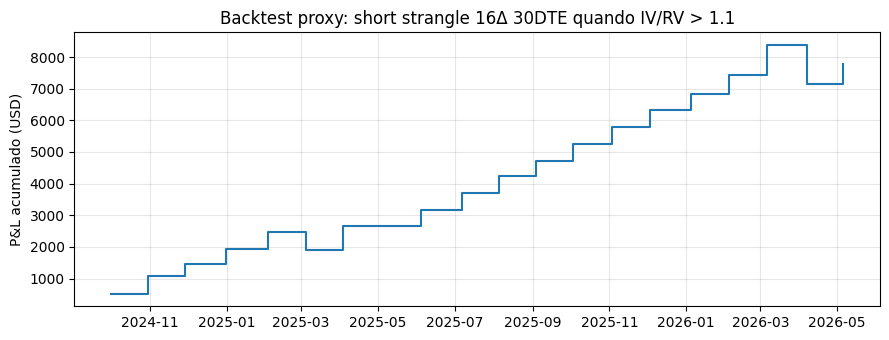

In [11]:
# @title 8a) Backtest proxy (funciona melhor com SPY/QQQ, que têm índice de vol)
LIMIAR_VRP_BT = 1.10
try:
    if TICKER in INDICES_VOL:
        vix_bt = yf.Ticker(INDICES_VOL[TICKER]).history(period="2y")["Close"]/100.0
        vix_bt.index = vix_bt.index.tz_localize(None).normalize()
    else:
        vix_bt = None
    px = hist["Close"].copy(); px.index = px.index.tz_localize(None).normalize()
    ret_bt = np.log(px/px.shift(1))
    rv20_bt = (ret_bt.rolling(20).std()*np.sqrt(252))

    trades = []
    i = 60
    while i < len(px)-22:
        t0 = px.index[i]
        S0 = float(px.iloc[i]); rv = float(rv20_bt.iloc[i])
        iv_bt = float(vix_bt.asof(t0)) if vix_bt is not None and np.isfinite(vix_bt.asof(t0)) else rv*1.05
        if np.isfinite(rv) and rv > 0 and iv_bt/rv > LIMIAR_VRP_BT:
            Tt = 30/365
            # strikes 16Δ via inversão do delta BSM
            d16 = norm.ppf(1-0.16)
            Kc = S0*np.exp((TAXA_JURO-DIV_YIELD+0.5*iv_bt**2)*Tt + d16*iv_bt*np.sqrt(Tt))
            Kp = S0*np.exp((TAXA_JURO-DIV_YIELD+0.5*iv_bt**2)*Tt - d16*iv_bt*np.sqrt(Tt))
            credito = (bs_price(S0,Kc,Tt,TAXA_JURO,iv_bt,"call",DIV_YIELD)
                       + bs_price(S0,Kp,Tt,TAXA_JURO,iv_bt,"put",DIV_YIELD))
            ST = float(px.iloc[min(i+21, len(px)-1)])
            pnl = (credito - max(ST-Kc,0) - max(Kp-ST,0))*100
            trades.append(dict(data=t0.date(), S0=S0, iv=iv_bt, rv=rv, pnl=pnl))
        i += 21

    if trades:
        bt = pd.DataFrame(trades)
        eq = bt.pnl.cumsum()
        wr = (bt.pnl > 0).mean()
        print(f"{len(bt)} trades em 2 anos | win rate {wr:.0%} | P&L médio {bt.pnl.mean():+.0f} USD | "
              f"pior trade {bt.pnl.min():+.0f} USD | total {bt.pnl.sum():+.0f} USD")
        print("Repara no padrão: win rate alto, perdas raras mas grandes → é por isso que o plano de gestão "
              "da célula 7b (fechar a 50%, stops) não é decoração.")
        fig, ax = plt.subplots(figsize=(9,3.5))
        ax.plot(pd.to_datetime(bt.data), eq, drawstyle="steps-post")
        ax.set_title(f"Backtest proxy: short strangle 16Δ 30DTE quando IV/RV > {LIMIAR_VRP_BT}")
        ax.set_ylabel("P&L acumulado (USD)"); ax.grid(alpha=.3)
        plt.tight_layout(); plt.show()
    else:
        print("Nenhum trade gerado (IV nunca esteve suficientemente cara no período, ou dados em falta).")
except Exception as e:
    print("Backtest indisponível:", e)

## 9) Interactive Brokers — dados reais, IV rank verdadeiro e gestão de posições

TWS/Gateway na tua máquina, API ativada (porta 7497 = paper). **Não funciona no Colab** (não vê o teu `localhost`) — descarrega o notebook e corre localmente. Começa sempre em paper.


In [12]:
# @title 9a) IBKR: cadeia com gregos do IB + IV HISTÓRICA REAL (IV rank verdadeiro)
USAR_IBKR = (FONTE == "ibkr")
if USAR_IBKR:
    from ib_async import IB, Stock, Option, util
    util.startLoop()
    ib = IB(); ib.connect("127.0.0.1", 7497, clientId=17)

    stk = Stock(TICKER, "SMART", "USD"); ib.qualifyContracts(stk)
    [tick] = ib.reqTickers(stk); SPOT = tick.marketPrice()

    # >>> IV HISTÓRICA REAL — resolve de vez a limitação do IV rank <<<
    barras_iv = ib.reqHistoricalData(stk, endDateTime="", durationStr="1 Y",
                                     barSizeSetting="1 day",
                                     whatToShow="OPTION_IMPLIED_VOLATILITY",
                                     useRTH=True, formatDate=1)
    if barras_iv:
        iv_serie = pd.Series([b.close for b in barras_iv])
        IV_PCTL = float((iv_serie < IV_ATM).mean()*100)
        IV_RANK = float((IV_ATM-iv_serie.min())/(iv_serie.max()-iv_serie.min())*100)
        IV_RANK_FONTE = "IB OPTION_IMPLIED_VOLATILITY (1 ano, real)"
        print(f"IV rank REAL via IB: {IV_RANK:.0f} | percentil {IV_PCTL:.0f}% — volta a correr as células 6→7b")

    chains = ib.reqSecDefOptParams(stk.symbol, "", stk.secType, stk.conId)
    ch = next(c for c in chains if c.exchange == "SMART")
    hoje_l = pd.Timestamp.now().normalize()
    exp_dtes = {e: (pd.Timestamp(e)-hoje_l).days for e in ch.expirations}
    EXPIRACAO = min(exp_dtes, key=lambda e: abs(exp_dtes[e]-DTE_ALVO))
    DTE = max(exp_dtes[EXPIRACAO],1); T = DTE/365.0
    strikes = [k for k in ch.strikes if SPOT*0.8 < k < SPOT*1.2]
    contratos = ib.qualifyContracts(*[Option(TICKER, EXPIRACAO, k, d, "SMART", tradingClass=ch.tradingClass)
                                      for k in strikes for d in ("C","P")])
    tickers = ib.reqTickers(*contratos)
    rows = []
    for t_ in tickers:
        g = t_.modelGreeks
        mid = t_.midpoint()
        if g is None or mid != mid: continue
        spr = (t_.ask-t_.bid)/mid if (mid and mid>0 and t_.ask>0 and t_.bid>0) else np.inf
        rows.append(dict(strike=t_.contract.strike, kind="call" if t_.contract.right=="C" else "put",
                         mid=mid, iv=g.impliedVol, delta=g.delta, gamma=g.gamma, vega=g.vega,
                         theta=g.theta, bid=t_.bid, ask=t_.ask, spread_pct=spr,
                         volume=t_.volume or 0, openInterest=0,
                         liq=float(np.clip(1-spr/SPREAD_MAX_PCT,0,1)*70 + np.clip((t_.volume or 0)/200,0,1)*30)))
    df_ib = pd.DataFrame(rows)
    calls = df_ib[df_ib.kind=="call"].sort_values("strike").reset_index(drop=True)
    puts  = df_ib[df_ib.kind=="put"].sort_values("strike").reset_index(drop=True)
    print(f"Cadeia IB: {len(calls)} calls / {len(puts)} puts — volta a correr 4b→7b com estes dados.")
else:
    print("FONTE='yfinance' — secção IB ignorada.")

FONTE='yfinance' — secção IB ignorada.


In [13]:
# @title 9b) IBKR: gestor de posições abertas (aplica o plano de gestão automaticamente)
if USAR_IBKR:
    hoje_l = pd.Timestamp.now().normalize()
    posicoes = [p for p in ib.portfolio()
                if p.contract.secType == "OPT" and p.contract.symbol == TICKER]
    if not posicoes:
        print(f"Sem posições de opções em {TICKER}.")
    for p in posicoes:
        con = p.contract
        dte_pos = (pd.Timestamp(con.lastTradeDateOrContractMonth)-hoje_l).days
        custo = p.averageCost            # por contrato (já ×100 no IB)
        valor = p.marketValue / max(abs(p.position),1)
        pnl_pct = (p.unrealizedPNL / abs(custo*p.position))*100 if custo else np.nan
        eh_vendida = p.position < 0
        flags = []
        if eh_vendida and np.isfinite(pnl_pct) and pnl_pct >= 50:
            flags.append("🎯 ≥50% do crédito capturado → FECHAR (regra da célula 7b)")
        if eh_vendida and np.isfinite(pnl_pct) and pnl_pct <= -200:
            flags.append("🛑 perda ≥2× crédito → STOP")
        if dte_pos <= 21:
            flags.append("⏳ ≤21 DTE → fechar ou rolar (gama a acelerar)")
        lado = "SHORT" if eh_vendida else "LONG"
        print(f"{lado} {abs(p.position):.0f}x {con.right} {con.strike} {con.lastTradeDateOrContractMonth} "
              f"({dte_pos} DTE) | P&L {p.unrealizedPNL:+.0f} USD ({pnl_pct:+.0f}%)"
              + ("".join("\n   " + f for f in flags) if flags else "  ✓ dentro do plano"))
else:
    print("FONTE='yfinance' — gestor de posições requer IB.")

FONTE='yfinance' — gestor de posições requer IB.


In [14]:
# @title 9c) IBKR: envio de ordem combo (EXEMPLO — deliberadamente comentado)
# ⚠️ Só descomentar em conta PAPER, com cada perna revista e a margem compreendida.
#
# if USAR_IBKR and LEGS:
#     from ib_async import Contract, ComboLeg, Order
#     combo = Contract(symbol=TICKER, secType="BAG", currency="USD", exchange="SMART")
#     combo.comboLegs = []
#     for L in LEGS:
#         opt = Option(TICKER, EXPIRACAO, L["strike"], "C" if L["kind"]=="call" else "P", "SMART")
#         ib.qualifyContracts(opt)
#         combo.comboLegs.append(ComboLeg(conId=opt.conId, ratio=1,
#                                         action="SELL" if L["lado"]=="vender" else "BUY", exchange="SMART"))
#     lim = round(sum((-L["mid"] if L["lado"]=="vender" else L["mid"]) for L in LEGS), 2)
#     trade = ib.placeOrder(combo, Order(action="BUY", orderType="LMT",
#                                        totalQuantity=1, lmtPrice=lim, tif="DAY"))
#     print(trade)
print("Exemplo de ordem no código (comentado por segurança).")

Exemplo de ordem no código (comentado por segurança).


In [15]:
# @title 10) Alertas — resumo acionável (agenda isto diariamente)
alertas = []
if IV_PCTL >= 80: alertas.append(f"🔴 IV no percentil {IV_PCTL:.0f}% — prémio gordo para vender ({IV_RANK_FONTE})")
if IV_PCTL <= 15: alertas.append(f"🟢 IV no percentil {IV_PCTL:.0f}% — opcionalidade barata para comprar")
if VRP_RATIO >= 1.3: alertas.append(f"🔴 IV a {VRP_RATIO:.2f}× a vol realizada — VRP invulgarmente rico")
if VRP_RATIO <= 0.85: alertas.append(f"🟢 IV abaixo da realizada ({VRP_RATIO:.2f}×) — mercado a subestimar movimento")
if np.isfinite(SKEW_25D) and SKEW_25D > 0.06: alertas.append(f"⚠️ Skew 25Δ a {SKEW_25D*100:+.1f} p.v. — medo de cauda elevado")
if np.isfinite(TERM_SLOPE) and TERM_SLOPE < -0.01: alertas.append("⚠️ Term structure invertida (backwardation) — stress")
if abs(SCORE) > 55: alertas.append(f"📈 Tendência forte ({DIRECAO}, score {SCORE:+.0f}) — cuidado com estruturas neutras")

print(f"═══ ALERTAS {TICKER} — {datetime.now():%Y-%m-%d %H:%M} ═══")
if alertas:
    for a in alertas: print(" ", a)
else:
    print("  Nada de extremo hoje. (O que, em opções, também é informação.)")
print(f"\nRegime: {ESTRATEGIA}")

# Para receber isto fora do notebook, agenda a execução (cron local, ou Colab
# 'Scheduled notebooks' no plano Pro) e descomenta um webhook à tua escolha:
# import requests
# requests.post("https://ntfy.sh/o-teu-topico-secreto", data="\n".join(alertas).encode("utf-8"))

═══ ALERTAS SPY — 2026-07-07 20:45 ═══
  🟢 IV no percentil 1% — opcionalidade barata para comprar
  📈 Tendência forte (bullish, score +67) — cuidado com estruturas neutras

Regime: BULL CALL SPREAD (debit spread)


## O que melhorou e o que (honestamente) ainda falta

**Resolvido nesta v2:** IV rank com fontes reais em cascata (IB → índice de vol → histórico próprio → só então proxy), direção por score composto, filtro e score de liquidez com aviso por perna, validação americana via árvore CRR com o prémio de exercício antecipado quantificado, POP + E[P&L] + probabilidade de tocar strikes, dimensionamento por risco máximo, plano de gestão explícito (50% / stop / 21 DTE / regras de rolar), term structure, skew 25Δ, backtest proxy e gestor de posições IB.

**Ainda em aberto (e vale a pena saber):**
- O backtest continua a ser um *proxy* — sem dados históricos de cadeias de opções (ORATS, CBOE DataShop, IVolatility são as fontes pagas habituais), não dá para backtestar gestão intra-trade nem spreads reais.
- O E[P&L] é risk-neutral por construção; medir o edge real exige comparar IV vendida vs. vol que efetivamente se realizou, trade a trade — o teu CSV de histórico começa a permitir isso com o tempo.
- Earnings e eventos: o notebook não verifica se há resultados antes da expiração (vender prémio através de earnings é outra modalidade, com outras regras). Confirma o calendário antes de entrar.
- Calendars/diagonais e ratio spreads ficaram de fora — estruturas com vega em duas expirações merecem tratamento próprio.

---
*Educativo, não é aconselhamento financeiro. A célula 2 continua a inverter Black-Scholes em microssegundos — abraço ao Marcelo.* 😉
